<a href="https://colab.research.google.com/github/LindsayRendon/campaigns-demo/blob/master/03_VAE_FashionMNIST_Generacion_Imagenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Generación de imágenes con VAE usando Fashion-MNIST

## 2. Objetivo
Entrenar un Autoencoder Variacional (VAE) capaz de comprimir imágenes de prendas de ropa, reconstruirlas y, lo más importante, generar imágenes de prendas completamente nuevas a partir de ruido aleatorio.

## 3. Qué problema resuelve
En la vida real, a veces no tenemos suficientes datos para entrenar modelos (por ejemplo, imágenes de enfermedades raras o diseños industriales). Los modelos generativos resuelven el problema de la **escasez de datos** creando muestras sintéticas realistas. Además, la parte de reconstrucción sirve para detectar anomalías (si el modelo no puede reconstruir bien una pieza en una fábrica, significa que la pieza tiene un defecto).

## 4. Dataset usado
**Fashion-MNIST**. Es un conjunto de datos alternativo al clásico MNIST de números. Contiene 60.000 imágenes en escala de grises de 28x28 píxeles de artículos de ropa (camisetas, pantalones, zapatillas, bolsos, etc.), divididas en 10 categorías.

---
### Conceptos teóricos clave aplicados en este Notebook:

* **¿Qué es un Autoencoder?** Es una red neuronal con forma de reloj de arena. Tiene dos partes: un **Encoder** (Codificador) que aplasta la imagen original reduciendo su información a un cuello de botella, y un **Decoder** (Decodificador) que intenta reconstruir la imagen original a partir de ese resumen comprimido.
* **Diferencia entre autoencoder clásico y VAE:** Un autoencoder clásico comprime la imagen en un punto exacto y fijo; es bueno para comprimir pero malo para inventar cosas nuevas. El **VAE (Variational Autoencoder)** no comprime en un punto fijo, sino en una "nube de probabilidad" (media y varianza). Esto hace que el espacio intermedio sea suave y continuo, permitiendo generar imágenes con sentido si tomamos un punto al azar de esa nube.
* **¿Qué es el espacio latente?** Es esa zona intermedia o "cuello de botella" de la red. Es una representación matemática de baja dimensión donde el modelo organiza los conceptos (por ejemplo, en una esquina del espacio latente agrupa los zapatos, y en otra las camisetas).
* **¿Qué significa generar datos nuevos?** Significa tomar coordenadas aleatorias de ese espacio latente (números al azar) y pasárselas al *Decoder*. Como el Decoder aprendió a transformar coordenadas en imágenes, "dibujará" una prenda que nunca existió pero que parece real.
* **Diferencia entre VAE y GAN:** * El **VAE** usa un Encoder y un Decoder, y minimiza el error de reconstrucción. Sus imágenes suelen tener sentido lógico pero a veces se ven un poco **borrosas**.
    * La **GAN** (Generative Adversarial Network) usa dos redes que compiten (un Falsificador y un Policía). Sus imágenes son extremadamente nítidas y realistas, pero es un modelo mucho más inestable y difícil de entrenar.

In [1]:
# 5. Librerías (Vamos a cargar las librerías)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, datasets

print("Librerías cargadas. Versión de TF:", tf.__version__)

Librerías cargadas. Versión de TF: 2.20.0


In [2]:
# 6. Carga y exploración de datos (Cargamos y preprocesamos las imágenes de ropa)
(x_train, _), (x_test, _) = datasets.fashion_mnist.load_data()

# 7. Preprocesamiento
# Normalizamos los valores de los píxeles para que estén entre 0 y 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Añadimos una dimensión extra al final (para indicar que tiene 1 canal de color: escala de grises)
# El tamaño pasará de (60000, 28, 28) a (60000, 28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Datos listos. Tamaño de x_train:", x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Datos listos. Tamaño de x_train: (60000, 28, 28, 1)


In [4]:
# Capa de muestreo (Sampling) para el VAE
# El VAE necesita una capa especial que "muestree" puntos al azar dentro del espacio latente basándose en la media y la varianza. Keras nos permite crear esta capa personalizada fácilmente
# Esta capa es la responsable de aplicar el "truco de reparametrización" matemático.
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        # Generamos un poco de ruido (epsilon) desde una distribución normal
        epsilon = tf.random.normal(shape=(batch, dim))
        # Retornamos un punto aleatorio alrededor de la media
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [5]:
# 8. Modelo: Construcción del Encoder y Decoder
# Ahora construimos el Encoder (que comprime) y el Decoder (que reconstruye). Usaremos un espacio latente de solo 2 dimensiones para poder visualizarlo si quisiéramos.
latent_dim = 2 # Vamos a comprimir una imagen de 784 píxeles en SOLO 2 números.

# --- ENCODER ---
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)

# El VAE no escupe un solo valor, escupe una media y una varianza
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Usamos nuestra capa especial para obtener el punto final 'z'
z = Sampling()([z_mean, z_log_var])

encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

# --- DECODER ---
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)

decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 9. Entrenamiento (Configuración del VAE)
# Para entrenar un VAE, necesitamos unir el Encoder y el Decoder, y además aplicarle una matemática especial a la pérdida (Pérdida de reconstrucción + Divergencia KL). Aquí creamos el modelo VAE final.
# Keras nos permite crear una clase modelo personalizada para definir cómo calcula el error
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # 1. Pasamos la imagen por el encoder
            z_mean, z_log_var, z = self.encoder(data)
            # 2. Pasamos el punto comprimido por el decoder para reconstruir
            reconstruction = self.decoder(z)

            # 3. Calculamos el Error de Reconstrucción (qué tan parecida es la copia a la original)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )

            # 4. Calculamos la Divergencia KL (matemática que fuerza a que el espacio latente sea continuo y ordenado)
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            # Error total
            total_loss = reconstruction_loss + kl_loss

        # Actualizamos los pesos usando Backpropagation
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

# Instanciamos y compilamos
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())

# ¡A entrenar! (Puede tomar un par de minutos, unas 30 épocas)
vae.fit(x_train, epochs=30, batch_size=128)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - kl_loss: 5.2876 - loss: 340.7928 - reconstruction_loss: 335.5052
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 5.3928 - loss: 330.8869 - reconstruction_loss: 325.4941
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 4.5785 - loss: 314.2348 - reconstruction_loss: 309.6562
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 4.4442 - loss: 306.9402 - reconstruction_loss: 302.4960
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 5.1937 - loss: 293.2267 - reconstruction_loss: 288.0330
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 5.3004 - loss: 301.1871 - reconstruction_loss: 295.8867
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 4.1305 - loss: 295.6213 - reconstruction_loss: 291.4908
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 4.8967 - loss: 285.7099 - reconstruction_loss: 280.8132
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 828ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step


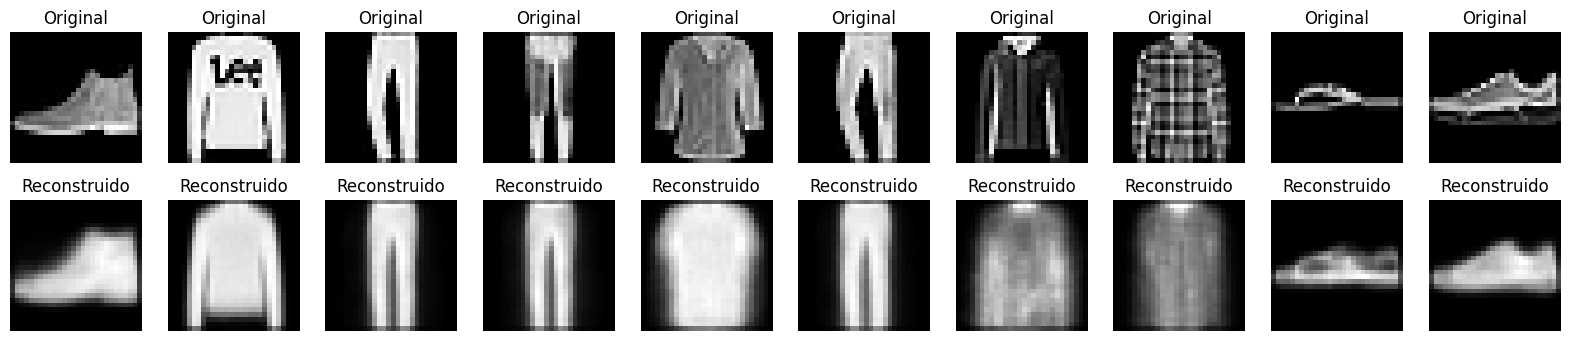

In [7]:
# 10. Evaluación: Imágenes Originales vs Reconstruidas
# Vamos a ver cómo reconstruye las imágenes (veremos si el modelo es capaz de comprimir a 2 números y descomprimir)
# Tomamos unas cuantas imágenes de test
ejemplos_reales = x_test[:10]

# Las pasamos por el encoder y el decoder
_, _, z_puntos = vae.encoder.predict(ejemplos_reales)
ejemplos_reconstruidos = vae.decoder.predict(z_puntos)

# Graficamos
plt.figure(figsize=(20, 4))
for i in range(10):
    # Fila superior: Originales
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(ejemplos_reales[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Fila inferior: Reconstrucciones
    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(ejemplos_reconstruidos[i].squeeze(), cmap='gray')
    plt.title("Reconstruido")
    plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


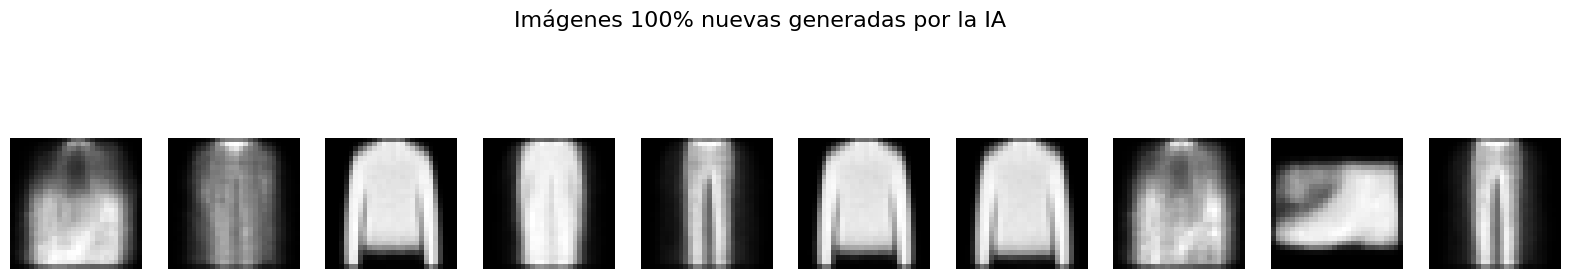

In [8]:
# 10. Evaluación: Generación de imágenes NUEVAS desde cero
# Vamos a obviar las imágenes originales. Le daremos al Decoder coordenadas 100% inventadas y aleatorias a ver qué dibuja.
# Generamos 10 coordenadas aleatorias (ruido puro) en nuestro espacio latente de 2D
random_latent_vectors = tf.random.normal(shape=(10, latent_dim))

# Se las pasamos directamente al DECODER (el creador)
generated_images = vae.decoder.predict(random_latent_vectors)

# Graficamos nuestras creaciones sintéticas
plt.figure(figsize=(20, 4))
plt.suptitle("Imágenes 100% nuevas generadas por la IA", fontsize=16)
for i in range(10):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.axis("off")
plt.show()

## 11. Conclusión
Hemos entrenado con éxito un modelo VAE. Como podemos observar en la celda de reconstrucción, el modelo es capaz de aplastar una imagen de ropa a tan solo 2 valores numéricos y luego recuperar su forma original (zapatos, camisetas, pantalones). Además, en la última prueba, le demostramos al modelo que puede generar piezas de ropa sintéticas partiendo de simple ruido matemático, lo cual es la base conceptual de todas las IA generativas actuales.

## 12. Qué aprendí
* **El aspecto borroso de los VAE:** Tal como predice la teoría, las imágenes reconstruidas y generadas tienen formas claras, pero se ven un poco borrosas y les faltan detalles afilados (cordones de zapatos, texturas). Esto es propio de la función de pérdida del VAE, que tiende a promediar los píxeles. Si necesitara ropa fotorrealista para un catálogo, habría elegido una arquitectura GAN.
* **El poder del espacio latente:** Me sorprendió que con solo un espacio latente de dimensión `latent_dim = 2` la red fuera capaz de retener tanta información visual. Esto demuestra el increíble nivel de abstracción que alcanzan las capas convolucionales en el proceso de "Encoding".
* **El Truco de Reparametrización:** Al crear la capa `Sampling`, entendí matemáticamente la diferencia entre un autoencoder clásico y uno variacional. En lugar de pasar un vector fijo, pasamos la suma de una media más una varianza multiplicada por ruido aleatorio. Esto es lo que permite que el espacio latente sea continuo y que podamos inyectarle ruido al decoder para crear algo nuevo.